Chọn dataset tabular trên Kaggle 
+ Tính hết các chỉ số thống kê liên quan (Quartiles, Inter-quartile range, Five number summary, Boxplot, Outlier, Variance, Standard deviation)
+ Vẽ một số biểu đồ cơ bản (distribution, boxplot, histogram, quantile plot, quantile-quantile (q-q) plot, scatter plot).

# Lab 1 - Thống kê mô tả và trực quan hóa (Netflix Titles)
Dataset: `netflix_titles.csv` (tabular dataset tu Kaggle).
Thực hiện đầy đủ:
- Quartiles, IQR, Five-number summary, Outlier, Variance, Standard deviation
- Distribution plot, Boxplot, Histogram, Quantile plot, Q-Q plot, Scatter plot, Heatmap

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('netflix_titles.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Tao cot so duration_min tu cot duration (vd: '90 min', '2 Seasons')
df['duration_min'] = (
    df['duration']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
    .where(df['type'].eq('Movie'), np.nan)
)

numeric_cols = ['release_year', 'duration_min']
analysis_df = df[numeric_cols].dropna()

print('Thong tin tong quan:')
print(df[numeric_cols].describe().T)

analysis_df.head()

Thong tin tong quan:
               count         mean        std     min     25%     50%     75%  \
release_year  8807.0  2014.180198   8.819312  1925.0  2013.0  2017.0  2019.0   
duration_min  6128.0    99.577187  28.290593     3.0    87.0    98.0   114.0   

                 max  
release_year  2021.0  
duration_min   312.0  


,release_year,duration_min
0,2020,90.0
6,2021,91.0
7,1993,125.0
9,2021,104.0
12,2021,127.0


In [3]:
def descriptive_stats_with_outlier(s: pd.Series) -> pd.Series:
    s = s.dropna()
    q1 = s.quantile(0.25)
    q2 = s.quantile(0.50)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (s < lower) | (s > upper)

    return pd.Series({
        'count': s.count(),
        'min': s.min(),
        'q1 (25%)': q1,
        'median (50%)': q2,
        'q3 (75%)': q3,
        'max': s.max(),
        'IQR': iqr,
        'lower_fence': lower,
        'upper_fence': upper,
        'outlier_count': outlier_mask.sum(),
        'outlier_ratio': outlier_mask.mean(),
        'variance': s.var(ddof=1),
        'std_dev': s.std(ddof=1),
    })

stats_table = pd.DataFrame({
    col: descriptive_stats_with_outlier(df[col]) for col in numeric_cols
}).T

print('Bang thong ke day du (bao gom Five-number summary, Quartiles, IQR, Outlier, Variance, Std):')
display(stats_table)

Bang thong ke day du (bao gom Five-number summary, Quartiles, IQR, Outlier, Variance, Std):


,count,min,q1 (25%),median (50%),q3 (75%),max,IQR,lower_fence,upper_fence,outlier_count,outlier_ratio,variance,std_dev
release_year,8807.0,1925.0,2013.0,2017.0,2019.0,2021.0,6.0,2004.0,2028.0,719.0,0.081640,77.780266,8.819312
duration_min,6128.0,3.0,87.0,98.0,114.0,312.0,27.0,46.5,154.5,450.0,0.073433,800.357678,28.290593


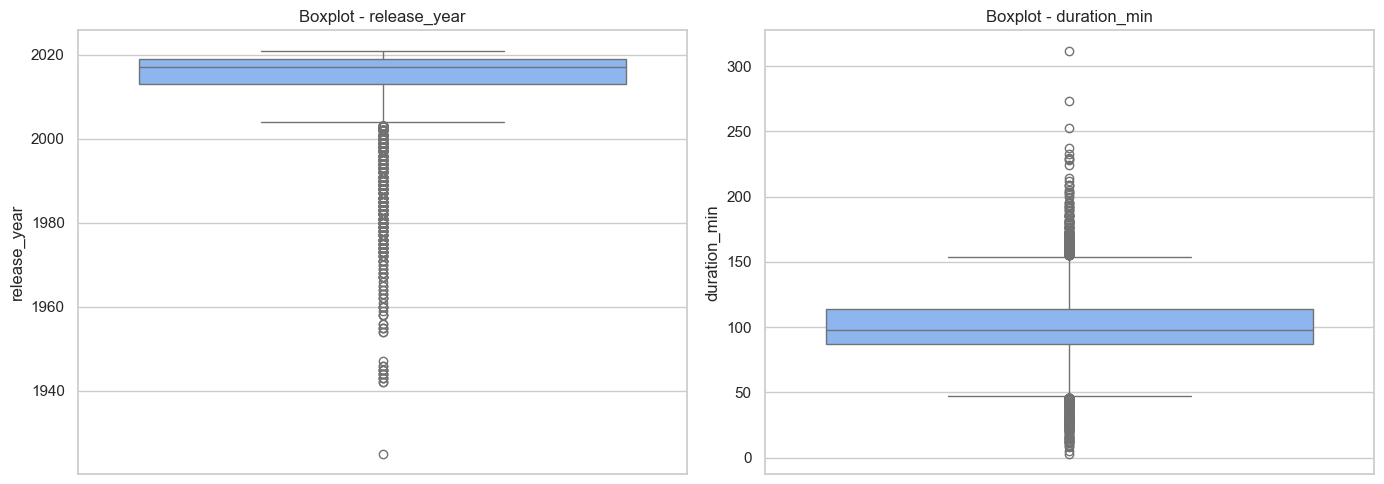

In [4]:
# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='#7DB3FF')
    ax.set_title(f'Boxplot - {col}')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

Giải thích Boxplot
- `release_year`: hộp tập trung mạnh ở giai đoạn gần đây (sau 2010), cho thấy phần lớn nội dung là phim/chương trình mới.
- `duration_min`: trung vị quanh khoảng 100 phút; có một số điểm ngoài râu biểu đồ thể hiện các phim rất ngắn hoặc rất dài (outlier).
- Boxplot giúp nhìn nhanh độ phân tán, độ lệch và outlier giữa hai biến số.

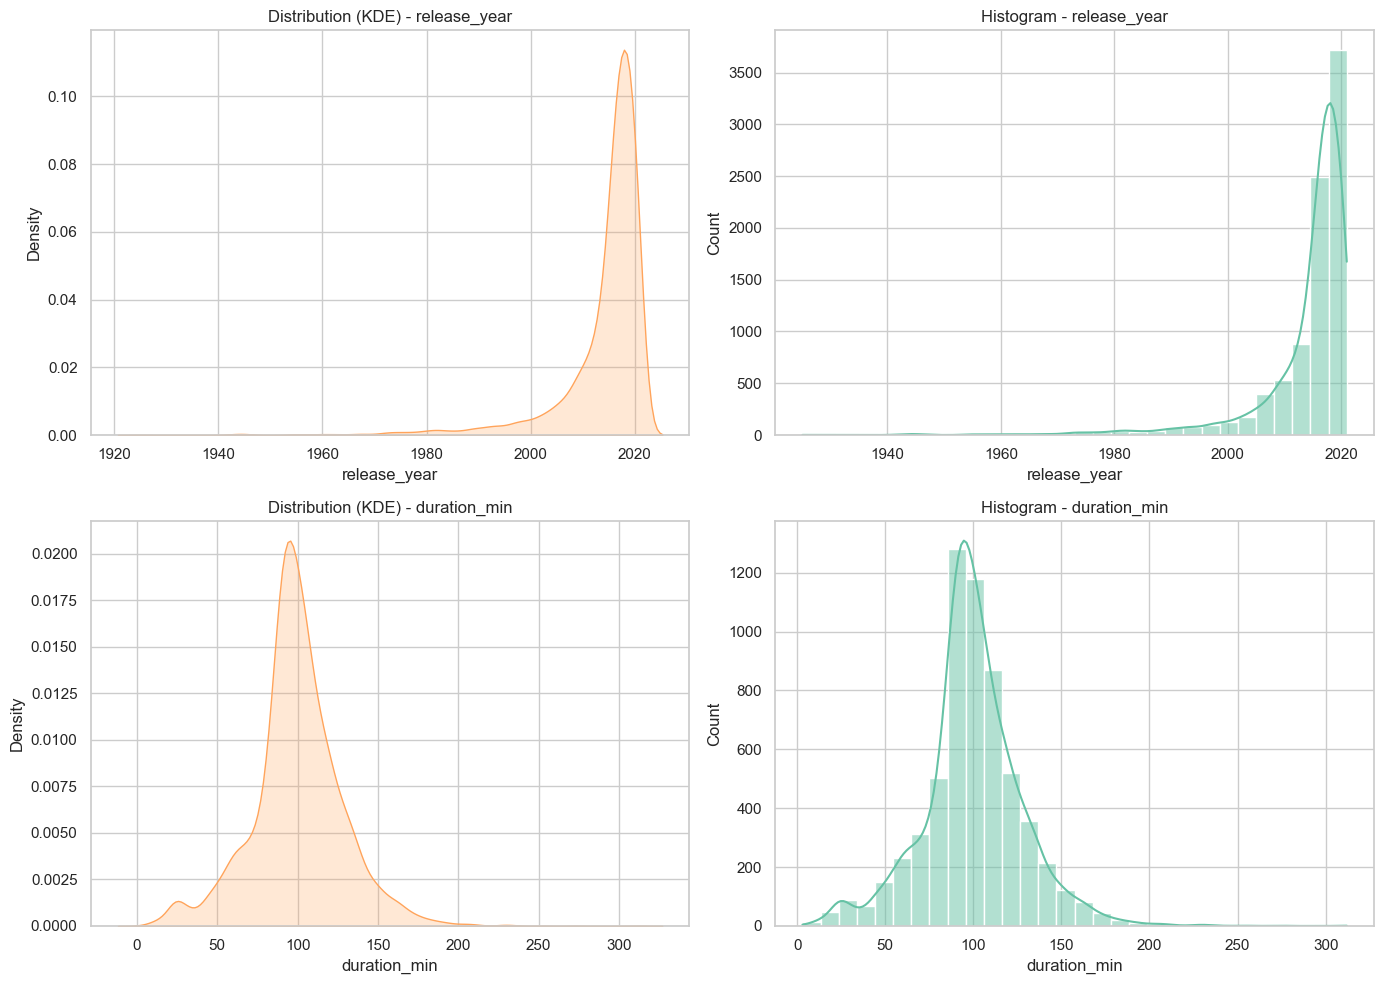

In [ ]:
# Distribution plot (KDE) + Histogram
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(numeric_cols):
    sns.kdeplot(x=df[col].dropna(), fill=True, ax=axes[i, 0], color='#FFA45B')
    axes[i, 0].set_title(f'Distribution (KDE) - {col}')

    sns.histplot(x=df[col].dropna(), bins=30, kde=True, ax=axes[i, 1], color='#66C2A5')
    axes[i, 1].set_title(f'Histogram - {col}')

plt.tight_layout()
plt.show()

Giải thích Distribution Plot và Histogram
- Đường KDE mô tả mật độ xác suất ước lượng của dữ liệu; histogram cho thấy tần suất theo từng khoảng giá trị.
- `release_year` có phân phối lệch về phía các năm gần đây, phản ánh số lượng tiêu đề tăng nhiều trong các năm mới.
- `duration_min` tập trung nhiều trong vùng khoảng 80-120 phút, ít hơn ở hai đầu phân phối.

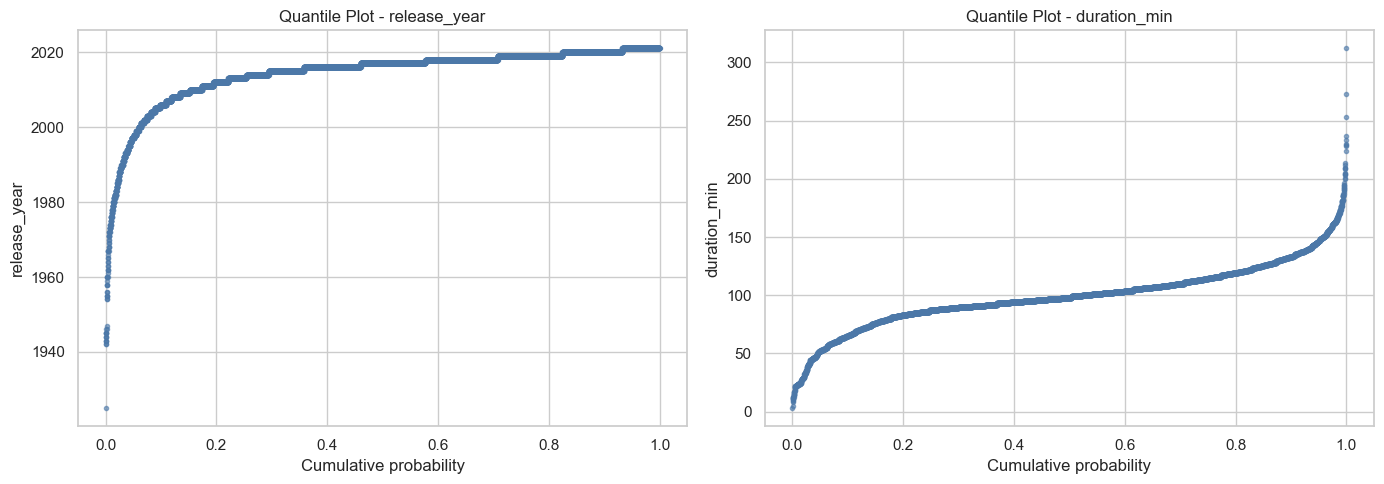

In [ ]:
# Quantile plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, numeric_cols):
    x = df[col].dropna().astype(float).sort_values().to_numpy()
    p = (np.arange(1, len(x) + 1) - 0.5) / len(x)
    ax.plot(p, x, marker='.', linestyle='none', alpha=0.6, color='#4C78A8')
    ax.set_title(f'Quantile Plot - {col}')
    ax.set_xlabel('Cumulative probability')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

Giải thích Quantile Plot
- Trục hoành là xác suất tích lũy, trục tung là giá trị đã sắp xếp tăng dần.
- Độ dốc đường cong thể hiện tốc độ thay đổi của dữ liệu theo các phân vị.
- Nếu đoạn cuối dốc mạnh, dữ liệu có xu hướng xuất hiện giá trị lớn bất thường ở phần đuôi trên.

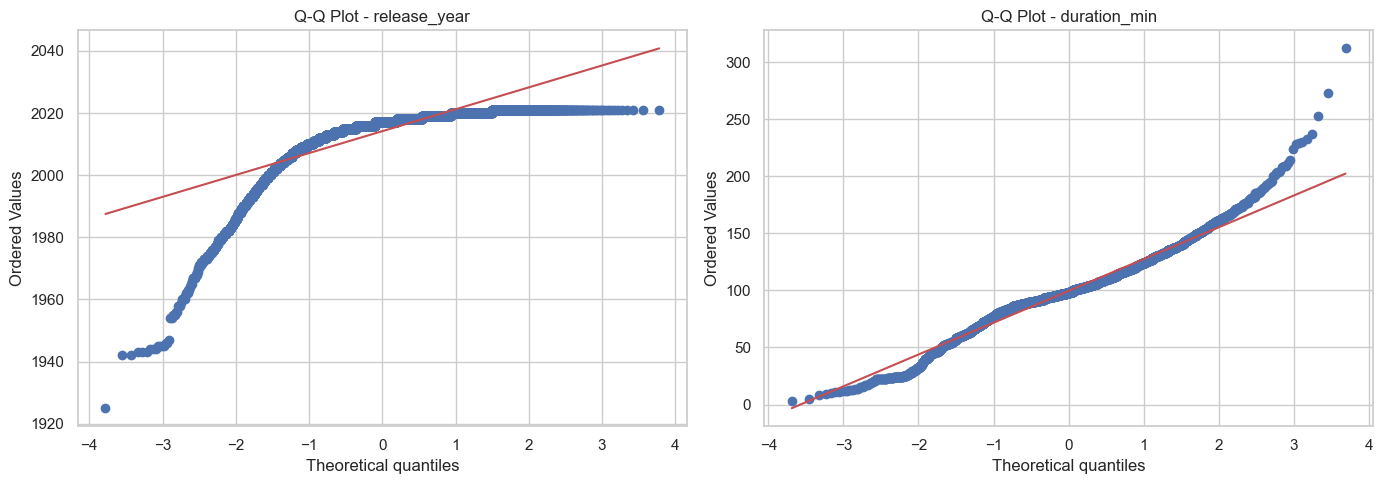

In [7]:
# Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, numeric_cols):
    stats.probplot(df[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot - {col}')
plt.tight_layout()
plt.show()

Giải thích Q-Q Plot
- Q-Q plot so sánh phân vị mẫu với phân vị của phân phối chuẩn.
- Điểm càng nằm sát đường thẳng tham chiếu thì dữ liệu càng gần phân phối chuẩn.
- Nếu hai đầu lệch khỏi đường nhiều, dữ liệu có đuôi dày/mỏng hơn chuẩn hoặc có outlier.

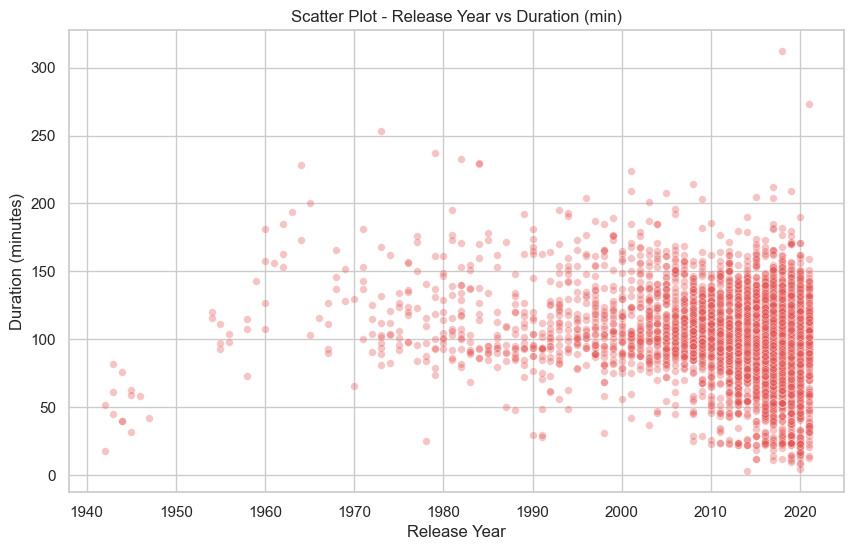

In [8]:
# Scatter plot: release_year vs duration_min (chi phim le)
movie_df = df[df['type'].eq('Movie')].dropna(subset=['release_year', 'duration_min'])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=movie_df,
    x='release_year',
    y='duration_min',
    alpha=0.35,
    s=30,
    color='#E45756'
    )
plt.title('Scatter Plot - Release Year vs Duration (min)')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.show()

Giải thích Scatter Plot
- Mỗi điểm biểu diễn một phim lẻ với cặp giá trị (`release_year`, `duration_min`).
- Tương quan giữa năm phát hành và thời lượng nhìn chung yếu (không có xu hướng tuyến tính rõ rệt).
- Biểu đồ giúp phát hiện các cụm dữ liệu theo giai đoạn năm và các điểm ngoại lệ có thời lượng bất thường.

Đánh giá kết quả
- **Boxplot:** Dữ liệu `release_year` tập trung ở các năm gần đây, trong khi `duration_min` có độ phân tán vừa phải và xuất hiện một số outlier ở hai đầu phân phối.
- **Distribution + Histogram:** Phân phối `release_year` lệch về các năm mới; `duration_min` tập trung chủ yếu quanh vùng 80-120 phút, phù hợp đặc trưng thời lượng phim phổ biến.
- **Quantile Plot:** Hai biến có xu hướng tăng không hoàn toàn tuyến tính theo phân vị; phần đuôi trên của `duration_min` tăng nhanh hơn, gợi ý một số phim có thời lượng cao bất thường.
- **Q-Q Plot:** Các điểm lệch khỏi đường tham chiếu ở hai đầu cho thấy dữ liệu chưa tuân theo phân phối chuẩn hoàn toàn, đặc biệt ở vùng giá trị cực trị.
- **Scatter Plot:** Mối liên hệ giữa năm phát hành và thời lượng phim yếu (không có xu hướng tuyến tính mạnh), nên `release_year` không phải biến dự báo tốt cho `duration_min` nếu dùng mô hình tuyến tính đơn giản.
- **Kết luận chung:** Bộ hình trực quan đã phản ánh đúng đặc tính dữ liệu: phân phối lệch, có outlier, và tương quan yếu giữa hai biến số chính.